In [ ]:
import ee

ee.Authenticate()
ee.Initialize(project='stubble-burning-project')

print(ee.String('GEE Working').getInfo())

GEE Working


In [ ]:
!pip -q install geemap

In [ ]:
import ee
import geemap

In [ ]:
Map = geemap.Map()

india_states = ee.FeatureCollection("FAO/GAUL/2015/level1")

punjab = india_states.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'India'),
        ee.Filter.eq('ADM1_NAME', 'Punjab')
    )
)

Map.centerObject(punjab, 7)
Map.addLayer(punjab, {'color': 'red'}, 'Punjab Boundary')
Map

Map(center=[30.835489716705656, 75.41103197707658], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(punjab)
      .filterDate('2023-10-15', '2023-11-30')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

In [ ]:
print("Number of images:", s2.size().getInfo())

Number of images: 142


In [ ]:
composite = s2.median().clip(punjab)

In [ ]:
vis_params = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000
}

Map.addLayer(composite, vis_params, 'Punjab Sentinel-2 2023')
Map

Map(bottom=13779.0, center=[30.38235321766959, 74.21813964843751], controls=(WidgetControl(options=['position'…

In [ ]:
def mask_s2_sr(image):
    scl = image.select('SCL')

    # Keep useful classes:
    # 4 = vegetation
    # 5 = bare soils
    # 6 = water
    # 7 = unclassified
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))

    return image.updateMask(mask)

In [ ]:
s2_masked = s2.map(mask_s2_sr)

In [ ]:
composite_masked = s2_masked.median().clip(punjab)

In [ ]:
vis_params = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000
}

Map.addLayer(composite_masked, vis_params, 'Punjab Masked Composite 2023')
Map

Map(bottom=13687.0, center=[31.25037814985571, 76.27258300781251], controls=(WidgetControl(options=['position'…

In [ ]:
ndvi = composite_masked.normalizedDifference(['B8', 'B4']).rename('NDVI')
nbr = composite_masked.normalizedDifference(['B8', 'B12']).rename('NBR')

composite_with_indices = composite_masked.addBands([ndvi, nbr])

In [ ]:
ndvi_vis = {
    'min': -1,
    'max': 1,
    'palette': ['blue', 'white', 'green']
}

Map.addLayer(ndvi, ndvi_vis, 'NDVI 2023')
Map

Map(bottom=13789.0, center=[30.287531589298727, 76.20666503906251], controls=(WidgetControl(options=['position…

In [ ]:
nbr_vis = {
    'min': -1,
    'max': 1,
    'palette': ['white', 'yellow', 'orange', 'red', 'black']
}

Map.addLayer(nbr, nbr_vis, 'NBR 2023')
Map

Map(bottom=7098.0, center=[29.267232865200903, 77.48657226562501], controls=(WidgetControl(options=['position'…

In [ ]:
final_image = composite_masked.select(['B2', 'B3', 'B4', 'B8', 'B11', 'B12']) \
    .addBands(ndvi) \
    .addBands(nbr)

print(final_image.bandNames().getInfo())

['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NBR']


In [ ]:
task = ee.batch.Export.image.toDrive(
    image=final_image,
    description='Punjab_2023_Stack',
    folder='EarthEngineExports',
    fileNamePrefix='Punjab_2023_Stack',
    region=punjab.geometry(),
    scale=20,
    maxPixels=1e13
)

task.start()
print("Export started")

Export started


In [ ]:
print(task.status())

{'state': 'FAILED', 'description': 'Punjab_2023_Stack', 'priority': 100, 'creation_timestamp_ms': 1774446419795, 'update_timestamp_ms': 1774446432505, 'start_timestamp_ms': 1774446426181, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'error_message': 'Exported bands must have compatible data types; found inconsistent types: Float64 and Float32.', 'id': '4SEOXHGB5OJHL252GDYMWB57', 'name': 'projects/stubble-burning-project/operations/4SEOXHGB5OJHL252GDYMWB57'}


In [ ]:
final_image = composite_masked.select(['B2', 'B3', 'B4', 'B8', 'B11', 'B12']) \
    .addBands(ndvi) \
    .addBands(nbr) \
    .toFloat()

print(final_image.bandNames().getInfo())

['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NBR']


In [ ]:
task = ee.batch.Export.image.toDrive(
    image=final_image,
    description='Punjab_2023_Stack',
    folder='EarthEngineExports',
    fileNamePrefix='Punjab_2023_Stack',
    region=punjab.geometry(),
    scale=20,
    maxPixels=1e13
)

task.start()
print("Export started")
print(task.status())

Export started
{'state': 'READY', 'description': 'Punjab_2023_Stack', 'priority': 100, 'creation_timestamp_ms': 1774446628859, 'update_timestamp_ms': 1774446628859, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'WD54MNZYDS4L2CVGN7B564XD', 'name': 'projects/stubble-burning-project/operations/WD54MNZYDS4L2CVGN7B564XD'}


In [ ]:
print(task.status())

{'state': 'RUNNING', 'description': 'Punjab_2023_Stack', 'priority': 100, 'creation_timestamp_ms': 1774446628859, 'update_timestamp_ms': 1774448429656, 'start_timestamp_ms': 1774446639971, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'batch_eecu_usage_seconds': 15973.409, 'id': 'WD54MNZYDS4L2CVGN7B564XD', 'name': 'projects/stubble-burning-project/operations/WD54MNZYDS4L2CVGN7B564XD'}


In [ ]:
print(task.status())

{'state': 'RUNNING', 'description': 'Punjab_2023_Stack', 'priority': 100, 'creation_timestamp_ms': 1774446628859, 'update_timestamp_ms': 1774448549945, 'start_timestamp_ms': 1774446639971, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'batch_eecu_usage_seconds': 15973.409, 'id': 'WD54MNZYDS4L2CVGN7B564XD', 'name': 'projects/stubble-burning-project/operations/WD54MNZYDS4L2CVGN7B564XD'}


In [ ]:
print(task.status())

NameError: name 'task' is not defined

In [ ]:
print(task.status())

NameError: name 'task' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

path = '/content/drive/MyDrive/EarthEngineExports'
print(os.listdir(path))

['Punjab_2023_Stack-0000000000-0000000000.tif', 'Punjab_2023_Stack-0000000000-0000011776.tif', 'Punjab_2023_Stack-0000011776-0000000000.tif', 'Punjab_2023_Stack-0000011776-0000011776.tif']


In [ ]:
import rasterio

file_path = '/content/drive/MyDrive/EarthEngineExports/Punjab_2023_Stack-0000000000-0000000000.tif'
dataset = rasterio.open(file_path)

print("Bands:", dataset.count)
print("Width:", dataset.width)
print("Height:", dataset.height)

Bands: 8
Width: 11776
Height: 11776


In [ ]:
image = dataset.read()
print(image.shape)

(8, 11776, 11776)


In [ ]:
import numpy as np

patch_size = 256
stride = 256  # no overlap

patches = []

for i in range(0, image.shape[1] - patch_size, stride):
    for j in range(0, image.shape[2] - patch_size, stride):
        patch = image[:, i:i+patch_size, j:j+patch_size]
        patches.append(patch)

patches = np.array(patches)

print("Total patches:", patches.shape[0])
print("Patch shape:", patches.shape)

Total patches: 2025
Patch shape: (2025, 8, 256, 256)


In [ ]:
Total patches: 2025
Patch shape: (2025, 8, 256, 256)

SyntaxError: invalid syntax (1832746594.py, line 1)

In [ ]:
patches = np.transpose(patches, (0, 2, 3, 1))
print("New shape:", patches.shape)

New shape: (2025, 256, 256, 8)


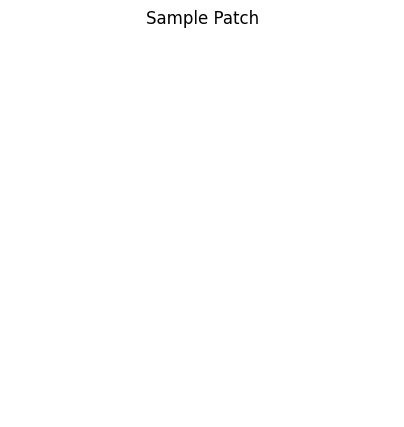

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sample = patches[0]
rgb = sample[:, :, [2, 1, 0]]  # B4, B3, B2

plt.figure(figsize=(5,5))
plt.imshow(np.clip(rgb / 3000, 0, 1))
plt.title("Sample Patch")
plt.axis('off')
plt.show()

In [ ]:
valid_indices = []

for idx in range(len(patches)):
    patch = patches[idx]
    if np.mean(patch[:, :, 0]) > 0:   # check B2 band
        valid_indices.append(idx)

print("Number of non-empty patches:", len(valid_indices))
print("First 10 valid indices:", valid_indices[:10])

Number of non-empty patches: 1083
First 10 valid indices: [87, 131, 132, 173, 174, 175, 176, 217, 218, 219]


In [ ]:
filtered_patches = patches[valid_indices]
print("Filtered patches shape:", filtered_patches.shape)

Filtered patches shape: (1083, 256, 256, 8)


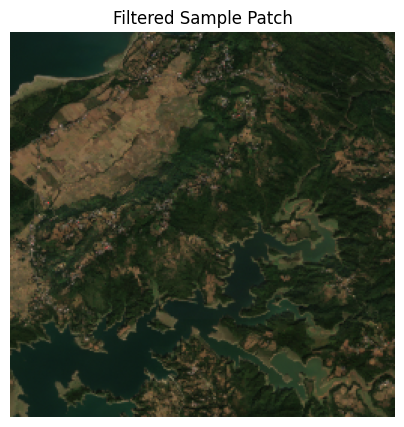

In [ ]:
sample = filtered_patches[0]
rgb = sample[:, :, [2, 1, 0]]

plt.figure(figsize=(5,5))
plt.imshow(np.clip(rgb / 3000, 0, 1))
plt.title("Filtered Sample Patch")
plt.axis('off')
plt.show()

NBR min: -0.617849
NBR max: 0.7515461


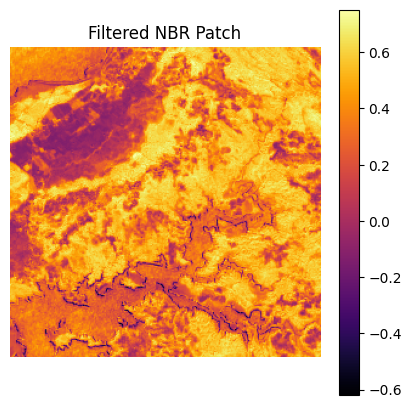

In [ ]:
nbr_patch = filtered_patches[0][:, :, 7]

print("NBR min:", np.min(nbr_patch))
print("NBR max:", np.max(nbr_patch))

plt.figure(figsize=(5,5))
plt.imshow(nbr_patch, cmap='inferno')
plt.title("Filtered NBR Patch")
plt.colorbar()
plt.axis('off')
plt.show()

In [ ]:
threshold = 0.1
masks = (filtered_patches[:, :, :, 7] < threshold).astype(np.uint8)

print("Mask shape:", masks.shape)
print("Unique values:", np.unique(masks))

Mask shape: (1083, 256, 256)
Unique values: [0 1]


In [ ]:
nbr_patch = filtered_patches[0][:, :, 7]
print("NBR min:", np.min(nbr_patch))
print("NBR max:", np.max(nbr_patch))

NBR min: -0.617849
NBR max: 0.7515461


In [ ]:
burn_ratio = np.mean(masks[0])
print("Burn ratio:", burn_ratio)

Burn ratio: 0.1339263916015625


In [ ]:
from sklearn.model_selection import train_test_split

X = filtered_patches
y = masks

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

NameError: name 'filtered_patches' is not defined

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

In [ ]:
file_path = '/content/drive/MyDrive/EarthEngineExports/Punjab_2023_Stack-0000000000-0000000000.tif'
dataset = rasterio.open(file_path)

image = dataset.read()
print(image.shape)

RasterioIOError: /content/drive/MyDrive/EarthEngineExports/Punjab_2023_Stack-0000000000-0000000000.tif: No such file or directory

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Getting started.pdf', 'INDEX.HTML', 'a.html', 'b.html', 'C.HTML', 'd.html', 'e.html', 'f.html', 'g.html', 'hindi.pdf', 'imgtopdf_generated_1410201434010.pdf', 'imgtopdf_generated_1510201632058.pdf', 'imgtopdf_generated_1610201644008.pdf', 'imgtopdf_generated_1910201657054.pdf', 'imgtopdf_generated_2010201655022.pdf', 'imgtopdf_generated_2110201646053.pdf', 'imgtopdf_generated_2210201404040.pdf', 'imgtopdf_generated_2210201644033.pdf', 'IMG_20201023_185140 (1).jpg', 'IMG_20201023_185140.jpg', 'IMG_20201023_185730.jpg', 'IMG_20201023_185751.jpg', 'imgtopdf_generated_2610201432023.pdf', 'imgtopdf_generated_2710201454048.pdf', 'imgtopdf_generated_3110201439044.pdf', "Share 'imgtopdf_generated_0511201253043.pdf'.pdf", 'yugansha panjwani math pdf.pdf', 'yugansha panjwani🐼 hindi paper.pdf', 'Yugansha Panjwani science.pdf', 'shraddha Panjwani english.pdf', 'english exam🐼 yugansha panjwani🐼.pdf', 'shraddhapanjwani math.pdf', 'shraddhapanjwani p.e..pdf', 'sst yugansha Panjwa

In [ ]:
print(os.listdir('/content/drive/MyDrive/EarthEngineExports'))

['Punjab_2023_Stack-0000000000-0000000000.tif', 'Punjab_2023_Stack-0000000000-0000011776.tif', 'Punjab_2023_Stack-0000011776-0000000000.tif', 'Punjab_2023_Stack-0000011776-0000011776.tif']


In [ ]:
import os
import numpy as np
import rasterio

folder = '/content/drive/MyDrive/EarthEngineExports'
files = os.listdir(folder)

file_path = os.path.join(folder, files[0])
print("Using:", file_path)
print("Exists:", os.path.exists(file_path))

dataset = rasterio.open(file_path)
image = dataset.read()

print("Image shape:", image.shape)

Using: /content/drive/MyDrive/EarthEngineExports/Punjab_2023_Stack-0000000000-0000000000.tif
Exists: True
Image shape: (8, 11776, 11776)


In [ ]:
patch_size = 256
stride = 256

patches = []

for i in range(0, image.shape[1] - patch_size, stride):
    for j in range(0, image.shape[2] - patch_size, stride):
        patch = image[:, i:i+patch_size, j:j+patch_size]
        patches.append(patch)

patches = np.array(patches)
print("Total patches:", patches.shape)

patches = np.transpose(patches, (0, 2, 3, 1))
print("Reshaped:", patches.shape)

valid_indices = []
for idx in range(len(patches)):
    if np.mean(patches[idx][:, :, 0]) > 0:
        valid_indices.append(idx)

filtered_patches = patches[valid_indices]
print("Filtered patches:", filtered_patches.shape)

filtered_patches = filtered_patches[:300]
print("Reduced dataset:", filtered_patches.shape)

threshold = 0.1
masks = (filtered_patches[:, :, :, 7] < threshold).astype(np.uint8)
print("Masks:", masks.shape)

Total patches: (2025, 8, 256, 256)
Reshaped: (2025, 256, 256, 8)
Filtered patches: (1083, 256, 256, 8)
Reduced dataset: (300, 256, 256, 8)
Masks: (300, 256, 256)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

filtered_patches = filtered_patches.astype('float32')
filtered_patches[:, :, :, 0:6] /= 3000.0

masks = masks.astype('float32')
masks = np.expand_dims(masks, axis=-1)

X_train, X_val, y_train, y_val = train_test_split(
    filtered_patches, masks, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import numpy as np
import rasterio
from sklearn.model_selection import train_test_split

folder = '/content/drive/MyDrive/EarthEngineExports'
file_path = os.path.join(folder, 'Punjab_2023_Stack-0000000000-0000000000.tif')

with rasterio.open(file_path) as dataset:
    image = dataset.read()

print("Loaded image:", image.shape)

patch_size = 128
stride = 128

patches = []
for i in range(0, image.shape[1] - patch_size, stride):
    for j in range(0, image.shape[2] - patch_size, stride):
        patch = image[:, i:i+patch_size, j:j+patch_size]
        if np.mean(patch[0]) > 0:
            patches.append(patch)

patches = np.array(patches, dtype=np.float32)
print("All valid patches:", patches.shape)

patches = patches[:120]
print("Reduced patches:", patches.shape)

patches = np.transpose(patches, (0, 2, 3, 1))
patches[:, :, :, 0:6] /= 3000.0

masks = (patches[:, :, :, 7] < 0.1).astype(np.float32)
masks = np.expand_dims(masks, axis=-1)

print("Patches:", patches.shape)
print("Masks:", masks.shape)

del image
gc.collect()

X_train, X_val, y_train, y_val = train_test_split(
    patches, masks, test_size=0.2, random_state=42
)

del patches, masks
gc.collect()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

Mounted at /content/drive


RasterioIOError: Read failed. See previous exception for details.

In [ ]:
import os

folder = '/content/drive/MyDrive/EarthEngineExports'
files = os.listdir(folder)

for f in files:
    os.remove(os.path.join(folder, f))

print("All files deleted")

All files deleted


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/EarthEngineExports'))

[]


In [ ]:
# Create a smaller region (center of Punjab)
small_region = punjab.geometry().centroid().buffer(20000)  # ~20 km area

task = ee.batch.Export.image.toDrive(
    image=final_image.toFloat(),
    description='Punjab_small',
    folder='EarthEngineExports',
    fileNamePrefix='Punjab_small',
    region=small_region,
    scale=20,
    maxPixels=1e13
)

task.start()
print("Small export started")

NameError: name 'punjab' is not defined

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'drive', 'sample_data']


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/EarthEngineExports'))

[]


In [ ]:
import ee
ee.Initialize(project='stubble-burning-project')

EEException: Please authorize access to your Earth Engine account by running

earthengine authenticate

in your command line, or ee.Authenticate() in Python, and then retry.

In [ ]:
import ee
ee.Authenticate()

In [ ]:
ee.Initialize(project='stubble-burning-project')
print("GEE initialized successfully")

GEE initialized successfully


In [ ]:
small_region = punjab.geometry().centroid().buffer(20000)

task = ee.batch.Export.image.toDrive(
    image=final_image.toFloat(),
    description='Punjab_small',
    folder='EarthEngineExports',
    fileNamePrefix='Punjab_small',
    region=small_region,
    scale=20,
    maxPixels=1e13
)

task.start()
print("Small export started")

NameError: name 'punjab' is not defined

In [ ]:
india_states = ee.FeatureCollection("FAO/GAUL/2015/level1")

punjab = india_states.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'India'),
        ee.Filter.eq('ADM1_NAME', 'Punjab')
    )
)

In [ ]:
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(punjab)
      .filterDate('2023-10-15', '2023-11-30')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

def mask_s2_sr(image):
    scl = image.select('SCL')
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    return image.updateMask(mask)

s2_masked = s2.map(mask_s2_sr)

composite = s2_masked.median().clip(punjab)

ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
nbr = composite.normalizedDifference(['B8', 'B12']).rename('NBR')

final_image = composite.select(['B2','B3','B4','B8','B11','B12']) \
    .addBands(ndvi) \
    .addBands(nbr)

In [ ]:
small_region = punjab.geometry().centroid().buffer(20000)

task = ee.batch.Export.image.toDrive(
    image=final_image.toFloat(),
    description='Punjab_small',
    folder='EarthEngineExports',
    fileNamePrefix='Punjab_small',
    region=small_region,
    scale=20,
    maxPixels=1e13
)

task.start()
print("Small export started")

Small export started


In [ ]:
import os
import rasterio
import numpy as np

folder = '/content/drive/MyDrive/EarthEngineExports'
files = [f for f in os.listdir(folder) if f.startswith('Punjab_small')]
print(files)

file_path = os.path.join(folder, files[0])
print("Using:", file_path)

with rasterio.open(file_path) as dataset:
    image = dataset.read()

print("Image shape:", image.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/EarthEngineExports'

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive'))

['.shortcut-targets-by-id', 'MyDrive', '.Trash-0']


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Getting started.pdf', 'INDEX.HTML', 'a.html', 'b.html', 'C.HTML', 'd.html', 'e.html', 'f.html', 'g.html', 'hindi.pdf', 'imgtopdf_generated_1410201434010.pdf', 'imgtopdf_generated_1510201632058.pdf', 'imgtopdf_generated_1610201644008.pdf', 'imgtopdf_generated_1910201657054.pdf', 'imgtopdf_generated_2010201655022.pdf', 'imgtopdf_generated_2110201646053.pdf', 'imgtopdf_generated_2210201404040.pdf', 'imgtopdf_generated_2210201644033.pdf', 'IMG_20201023_185140 (1).jpg', 'IMG_20201023_185140.jpg', 'IMG_20201023_185730.jpg', 'IMG_20201023_185751.jpg', 'imgtopdf_generated_2610201432023.pdf', 'imgtopdf_generated_2710201454048.pdf', 'imgtopdf_generated_3110201439044.pdf', "Share 'imgtopdf_generated_0511201253043.pdf'.pdf", 'yugansha panjwani math pdf.pdf', 'yugansha panjwani🐼 hindi paper.pdf', 'Yugansha Panjwani science.pdf', 'shraddha Panjwani english.pdf', 'english exam🐼 yugansha panjwani🐼.pdf', 'shraddhapanjwani math.pdf', 'shraddhapanjwani p.e..pdf', 'sst yugansha Panjwa

In [ ]:
folder = '/content/drive/MyDrive/EarthEngineExports'
print("Folder exists:", os.path.exists(folder))

Folder exists: True


In [ ]:
print(os.listdir('/content/drive/MyDrive/EarthEngineExports'))

['Punjab_small.tif']


In [ ]:
import os
import rasterio
import numpy as np

file_path = '/content/drive/MyDrive/EarthEngineExports/Punjab_small.tif'

with rasterio.open(file_path) as dataset:
    image = dataset.read()

print("Image shape:", image.shape)

Image shape: (8, 2004, 2319)


In [ ]:
patch_size = 128
stride = 128

patches = []
for i in range(0, image.shape[1] - patch_size, stride):
    for j in range(0, image.shape[2] - patch_size, stride):
        patch = image[:, i:i+patch_size, j:j+patch_size]
        if np.mean(patch[0]) > 0:
            patches.append(patch)

patches = np.array(patches, dtype=np.float32)
print("Valid patches:", patches.shape)

patches = patches[:120]
print("Reduced patches:", patches.shape)

patches = np.transpose(patches, (0, 2, 3, 1))
patches[:, :, :, 0:6] /= 3000.0

masks = (patches[:, :, :, 7] < 0.1).astype(np.float32)
masks = np.expand_dims(masks, axis=-1)

print("Patches:", patches.shape)
print("Masks:", masks.shape)

Valid patches: (270, 8, 128, 128)
Reduced patches: (120, 8, 128, 128)
Patches: (120, 128, 128, 8)
Masks: (120, 128, 128, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    patches, masks, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (96, 128, 128, 8)
X_val: (24, 128, 128, 8)
y_train: (96, 128, 128, 1)
y_val: (24, 128, 128, 1)


In [ ]:
import gc
import tensorflow as tf
from tensorflow.keras import layers, models

gc.collect()
tf.keras.backend.clear_session()

def tiny_unet(input_shape=(128, 128, 8)):
    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(8, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(8, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(16, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(16, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    b1 = layers.Conv2D(32, 3, activation='relu', padding='same')(p2)
    b1 = layers.Conv2D(32, 3, activation='relu', padding='same')(b1)

    u1 = layers.UpSampling2D((2, 2))(b1)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(16, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(16, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D((2, 2))(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(8, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(8, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    return models.Model(inputs, outputs)

model = tiny_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        584 │ input_layer[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │        584 │ conv2d[0][0]      │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64, 8) │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      1,168 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      2,320 │ conv2d_2[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      4,640 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 48)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │      6,928 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │      2,320 │ conv2d_6[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 24)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │      1,736 │ concatenate_1[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │        584 │ conv2d_8[0][0]  

 Total params: 30,121 (117.66 KB)

 Trainable params: 30,121 (117.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=1,
    epochs=2
)

Epoch 1/2
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.6752 - loss: 0.5402 - val_accuracy: 0.8721 - val_loss: 0.3888
Epoch 2/2
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8981 - loss: 0.2428 - val_accuracy: 0.9189 - val_loss: 0.1920


In [ ]:
pred = model.predict(X_val[:1])
print(pred.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
(1, 128, 128, 1)


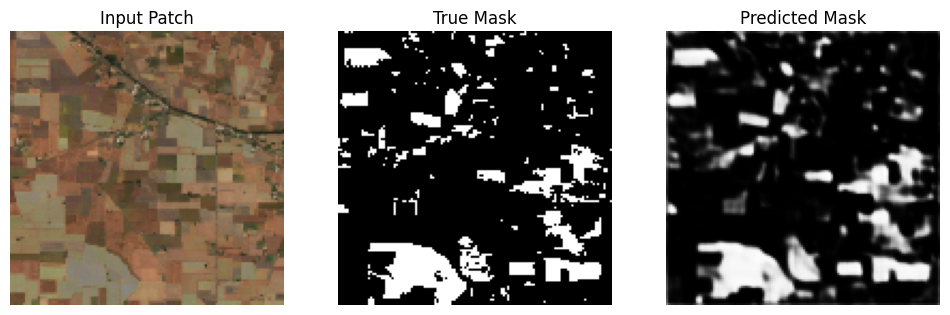

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sample_img = X_val[0]
true_mask = y_val[0, :, :, 0]
pred_mask = pred[0, :, :, 0]

rgb = sample_img[:, :, [2, 1, 0]]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.clip(rgb, 0, 1))
plt.title("Input Patch")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(true_mask, cmap='gray')
plt.title("True Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

plt.show()

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=1,
    epochs=5
)

Epoch 1/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9268 - loss: 0.1705 - val_accuracy: 0.9341 - val_loss: 0.1565
Epoch 2/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9382 - loss: 0.1459 - val_accuracy: 0.9422 - val_loss: 0.1369
Epoch 3/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9441 - loss: 0.1323 - val_accuracy: 0.9471 - val_loss: 0.1258
Epoch 4/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9500 - loss: 0.1196 - val_accuracy: 0.9498 - val_loss: 0.1198
Epoch 5/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9528 - loss: 0.1127 - val_accuracy: 0.9520 - val_loss: 0.1144


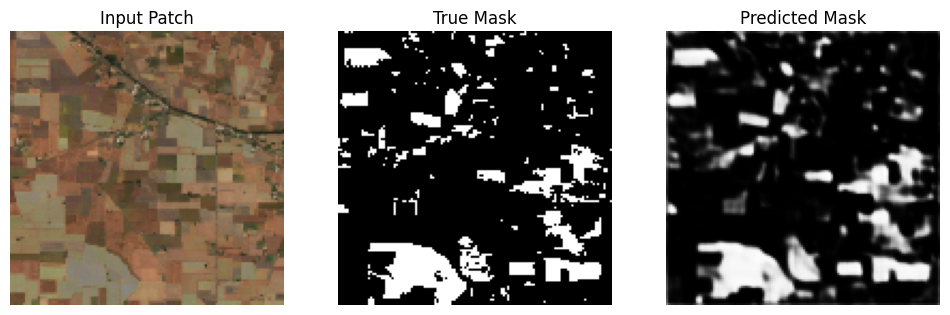

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sample_img = X_val[0]
true_mask = y_val[0, :, :, 0]
pred_mask = pred[0, :, :, 0]

rgb = sample_img[:, :, [2, 1, 0]]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.clip(rgb, 0, 1))
plt.title("Input Patch")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(true_mask, cmap='gray')
plt.title("True Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

plt.show()

In [ ]:
model.save('/content/drive/MyDrive/EarthEngineExports/tiny_unet_punjab_small.keras')
print("Model saved successfully")

Model saved successfully


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/EarthEngineExports'))

['Punjab_small.tif', 'tiny_unet_punjab_small.keras']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


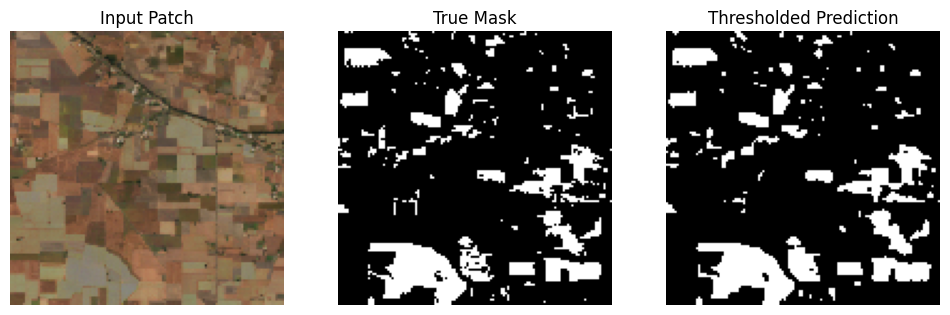

In [ ]:
pred = model.predict(X_val[:1])

sample_img = X_val[0]
true_mask = y_val[0, :, :, 0]
pred_mask = (pred[0, :, :, 0] > 0.5).astype('float32')

rgb = sample_img[:, :, [2, 1, 0]]

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.clip(rgb, 0, 1))
plt.title("Input Patch")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(true_mask, cmap='gray')
plt.title("True Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap='gray')
plt.title("Thresholded Prediction")
plt.axis('off')

plt.show()

In [ ]:
for t in [0.0, 0.1, 0.2]:
    temp_masks = (patches[:, :, :, 7] < t).astype(np.float32)
    print("Threshold:", t, "Burn ratio:", np.mean(temp_masks))

Threshold: 0.0 Burn ratio: 0.11601664
Threshold: 0.1 Burn ratio: 0.31857604
Threshold: 0.2 Burn ratio: 0.5365046


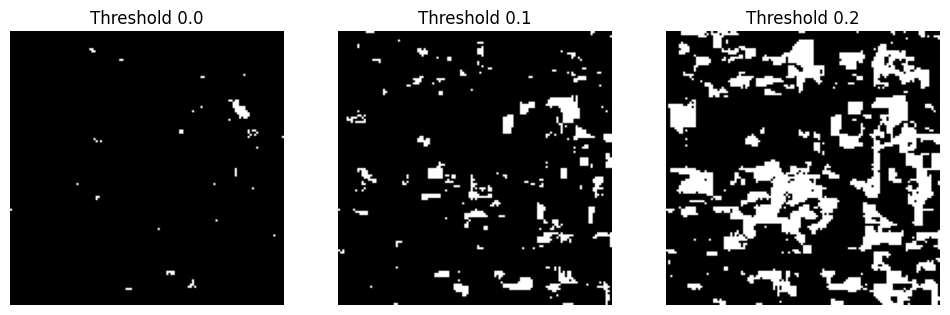

In [ ]:
thresholds = [0.0, 0.1, 0.2]

plt.figure(figsize=(12,4))
for i, t in enumerate(thresholds):
    temp_mask = (patches[0, :, :, 7] < t).astype(np.float32)
    plt.subplot(1,3,i+1)
    plt.imshow(temp_mask, cmap='gray')
    plt.title(f"Threshold {t}")
    plt.axis('off')

plt.show()

In [ ]:
region1 = punjab.geometry().centroid().buffer(20000)
region2 = punjab.geometry().centroid().translate(20000, 20000).buffer(20000)
region3 = punjab.geometry().centroid().translate(-20000, -20000).buffer(20000)

NameError: name 'punjab' is not defined

In [ ]:
import ee
ee.Initialize(project='stubble-burning-project')

EEException: Please authorize access to your Earth Engine account by running

earthengine authenticate

in your command line, or ee.Authenticate() in Python, and then retry.

In [ ]:
import ee
ee.Authenticate()

In [ ]:
ee.Initialize(project='stubble-burning-project')
print("GEE ready")

GEE ready


In [ ]:
india_states = ee.FeatureCollection("FAO/GAUL/2015/level1")

punjab = india_states.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'India'),
        ee.Filter.eq('ADM1_NAME', 'Punjab')
    )
)

In [ ]:
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(punjab)
      .filterDate('2023-10-15', '2023-11-30')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

def mask_s2_sr(image):
    scl = image.select('SCL')
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    return image.updateMask(mask)

s2_masked = s2.map(mask_s2_sr)

composite = s2_masked.median().clip(punjab)

ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
nbr = composite.normalizedDifference(['B8', 'B12']).rename('NBR')

final_image = composite.select(['B2','B3','B4','B8','B11','B12']) \
    .addBands(ndvi) \
    .addBands(nbr)

In [ ]:
region2 = punjab.geometry().centroid().translate(20000, 20000).buffer(20000)

task2 = ee.batch.Export.image.toDrive(
    image=final_image.toFloat(),
    description='Punjab_small_2',
    folder='EarthEngineExports',
    fileNamePrefix='Punjab_small_2',
    region=region2,
    scale=20,
    maxPixels=1e13
)

task2.start()
print("Second region export started")

AttributeError: 'Geometry' object has no attribute 'translate'

In [ ]:
centroid = punjab.geometry().centroid()
coords = centroid.coordinates().getInfo()

lon = coords[0]
lat = coords[1]

print("Center:", lon, lat)

Center: 75.41103197707658 30.835489716705656


In [ ]:
region2 = ee.Geometry.Point([lon + 0.2, lat + 0.2]).buffer(20000)
region3 = ee.Geometry.Point([lon - 0.2, lat - 0.2]).buffer(20000)

In [ ]:
task2 = ee.batch.Export.image.toDrive(
    image=final_image.toFloat(),
    description='Punjab_small_2',
    folder='EarthEngineExports',
    fileNamePrefix='Punjab_small_2',
    region=region2,
    scale=20,
    maxPixels=1e13
)

task2.start()
print("Second region export started")

Second region export started


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/EarthEngineExports'))

['Punjab_small.tif', 'tiny_unet_punjab_small.keras', 'Punjab_small_2.tif']


In [ ]:
import rasterio
import numpy as np

file1 = '/content/drive/MyDrive/EarthEngineExports/Punjab_small.tif'
file2 = '/content/drive/MyDrive/EarthEngineExports/Punjab_small_2.tif'

with rasterio.open(file1) as ds1:
    image1 = ds1.read()

with rasterio.open(file2) as ds2:
    image2 = ds2.read()

print("Image1:", image1.shape)
print("Image2:", image2.shape)

Image1: (8, 2004, 2319)
Image2: (8, 2004, 2324)


In [ ]:
def create_patches(image, patch_size=128, stride=128):
    patches = []
    for i in range(0, image.shape[1] - patch_size, stride):
        for j in range(0, image.shape[2] - patch_size, stride):
            patch = image[:, i:i+patch_size, j:j+patch_size]
            if np.mean(patch[0]) > 0:
                patches.append(patch)
    return np.array(patches, dtype=np.float32)

In [ ]:
patches1 = create_patches(image1)
patches2 = create_patches(image2)

print("Patches1:", patches1.shape)
print("Patches2:", patches2.shape)

Patches1: (270, 8, 128, 128)
Patches2: (270, 8, 128, 128)


In [ ]:
patches1 = patches1[:120]
patches2 = patches2[:120]

print("Reduced Patches1:", patches1.shape)
print("Reduced Patches2:", patches2.shape)

Reduced Patches1: (120, 8, 128, 128)
Reduced Patches2: (120, 8, 128, 128)


In [ ]:
all_patches = np.concatenate([patches1, patches2], axis=0)
print("Combined patches:", all_patches.shape)

Combined patches: (240, 8, 128, 128)


In [ ]:
all_patches = np.transpose(all_patches, (0, 2, 3, 1))
all_patches[:, :, :, 0:6] /= 3000.0

all_masks = (all_patches[:, :, :, 7] < 0.1).astype(np.float32)
all_masks = np.expand_dims(all_masks, axis=-1)

print("All patches:", all_patches.shape)
print("All masks:", all_masks.shape)

All patches: (240, 128, 128, 8)
All masks: (240, 128, 128, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train2, X_val2, y_train2, y_val2 = train_test_split(
    all_patches, all_masks, test_size=0.2, random_state=42
)

print("X_train2:", X_train2.shape)
print("X_val2:", X_val2.shape)
print("y_train2:", y_train2.shape)
print("y_val2:", y_val2.shape)

X_train2: (192, 128, 128, 8)
X_val2: (48, 128, 128, 8)
y_train2: (192, 128, 128, 1)
y_val2: (48, 128, 128, 1)


In [ ]:
import gc
import tensorflow as tf
from tensorflow.keras import layers, models

gc.collect()
tf.keras.backend.clear_session()

def tiny_unet_v2(input_shape=(128, 128, 8)):
    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(8, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(8, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(16, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(16, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    b1 = layers.Conv2D(32, 3, activation='relu', padding='same')(p2)
    b1 = layers.Conv2D(32, 3, activation='relu', padding='same')(b1)

    u1 = layers.UpSampling2D((2, 2))(b1)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(16, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(16, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D((2, 2))(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(8, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(8, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    return models.Model(inputs, outputs)

model_v2 = tiny_unet_v2()
model_v2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_v2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        584 │ input_layer[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │        584 │ conv2d[0][0]      │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64, 8) │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      1,168 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      2,320 │ conv2d_2[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      4,640 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 48)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │      6,928 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │      2,320 │ conv2d_6[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 24)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │      1,736 │ concatenate_1[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │        584 │ conv2d_8[0][0]  

 Total params: 30,121 (117.66 KB)

 Trainable params: 30,121 (117.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_v2 = model_v2.fit(
    X_train2, y_train2,
    validation_data=(X_val2, y_val2),
    batch_size=1,
    epochs=3
)

Epoch 1/3
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8644 - loss: 0.3090 - val_accuracy: 0.9184 - val_loss: 0.1877
Epoch 2/3
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9332 - loss: 0.1576 - val_accuracy: 0.9446 - val_loss: 0.1335
Epoch 3/3
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9496 - loss: 0.1212 - val_accuracy: 0.9539 - val_loss: 0.1117


In [ ]:
model_v2.save('/content/drive/MyDrive/EarthEngineExports/tiny_unet_punjab_small_v2.keras')
print("Improved model saved")

Improved model saved


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step


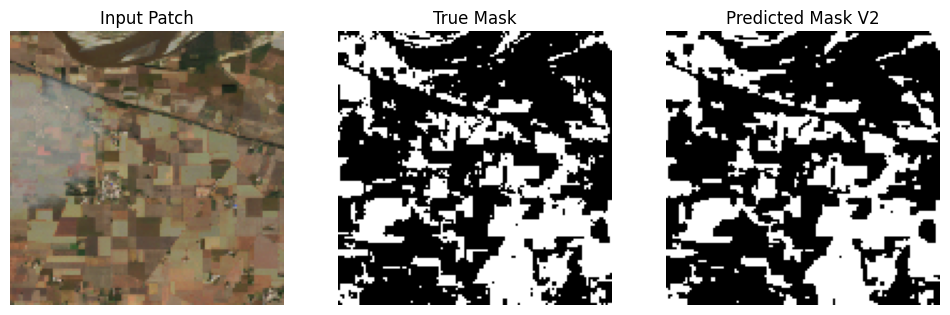

In [ ]:
pred2 = model_v2.predict(X_val2[:1])

import matplotlib.pyplot as plt
import numpy as np

sample_img = X_val2[0]
true_mask = y_val2[0, :, :, 0]
pred_mask = (pred2[0, :, :, 0] > 0.5).astype('float32')

rgb = sample_img[:, :, [2, 1, 0]]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.clip(rgb, 0, 1))
plt.title("Input Patch")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(true_mask, cmap='gray')
plt.title("True Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap='gray')
plt.title("Predicted Mask V2")
plt.axis('off')

plt.show()

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/EarthEngineExports'))

['Punjab_small.tif', 'tiny_unet_punjab_small.keras', 'Punjab_small_2.tif', 'tiny_unet_punjab_small_v2.keras']


In [ ]:
all_masks = (all_patches[:, :, :, 7] < -0.1).astype(np.float32)

In [ ]:
history_v3 = model_v2.fit(
    X_train2, y_train2,
    validation_data=(X_val2, y_val2),
    batch_size=1,
    epochs=2
)

Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9568 - loss: 0.1038 - val_accuracy: 0.9627 - val_loss: 0.0915
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9656 - loss: 0.0839 - val_accuracy: 0.9684 - val_loss: 0.0778


In [ ]:
pred3 = model_v2.predict(X_val2[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


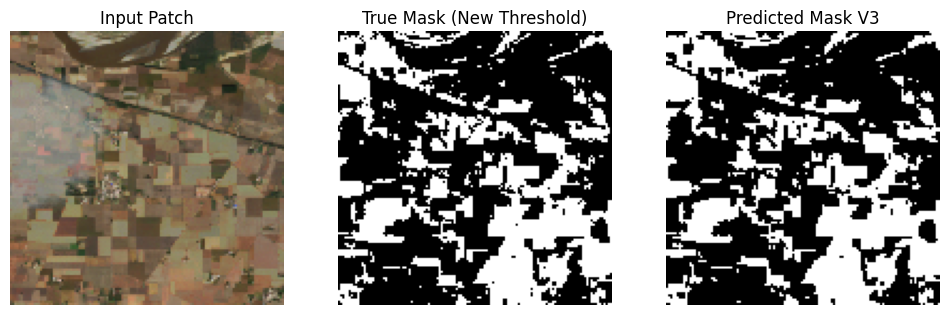

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sample_img = X_val2[0]
true_mask = y_val2[0, :, :, 0]
pred_mask = (pred3[0, :, :, 0] > 0.5).astype('float32')

rgb = sample_img[:, :, [2, 1, 0]]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.clip(rgb, 0, 1))
plt.title("Input Patch")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(true_mask, cmap='gray')
plt.title("True Mask (New Threshold)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap='gray')
plt.title("Predicted Mask V3")
plt.axis('off')

plt.show()

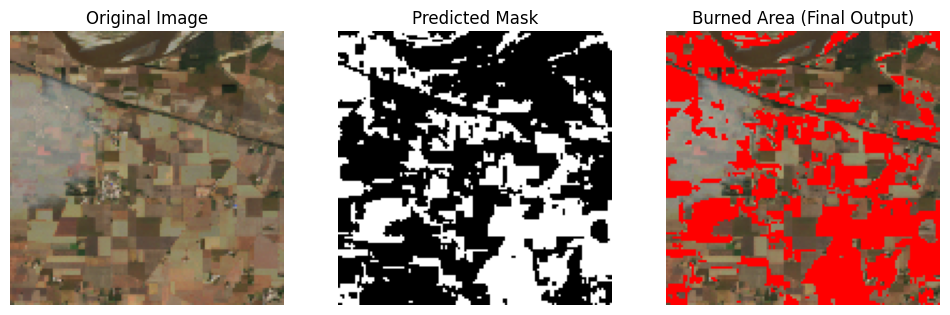

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sample_img = X_val2[0]
pred_mask = (pred3[0, :, :, 0] > 0.5)

# RGB image
rgb = sample_img[:, :, [2, 1, 0]]

# Create overlay (red = burned area)
overlay = rgb.copy()
overlay[pred_mask] = [1, 0, 0]  # red color

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.clip(rgb, 0, 1))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(pred_mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.clip(overlay, 0, 1))
plt.title("Burned Area (Final Output)")
plt.axis('off')

plt.show()

In [ ]:
centroid = punjab.geometry().centroid()
coords = centroid.coordinates().getInfo()

lon = coords[0]
lat = coords[1]

region3 = ee.Geometry.Point([lon - 0.2, lat - 0.2]).buffer(20000)

NameError: name 'punjab' is not defined

In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project='stubble-burning-project')
print("GEE ready")

GEE ready


In [ ]:
india_states = ee.FeatureCollection("FAO/GAUL/2015/level1")

punjab = india_states.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'India'),
        ee.Filter.eq('ADM1_NAME', 'Punjab')
    )
)

print("Punjab loaded")

Punjab loaded


In [ ]:
centroid = punjab.geometry().centroid()
coords = centroid.coordinates().getInfo()

lon = coords[0]
lat = coords[1]

print(lon, lat)

75.41103197707658 30.835489716705627


In [ ]:
centroid = punjab.geometry().centroid()
coords = centroid.coordinates().getInfo()

lon = coords[0]
lat = coords[1]

region3 = ee.Geometry.Point([lon - 0.2, lat - 0.2]).buffer(20000)

In [ ]:
task3 = ee.batch.Export.image.toDrive(
    image=final_image.toFloat(),
    description='Punjab_small_3',
    folder='EarthEngineExports',
    fileNamePrefix='Punjab_small_3',
    region=region3,
    scale=20,
    maxPixels=1e13
)

task3.start()
print("Third region export started")

NameError: name 'final_image' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project='stubble-burning-project')

In [ ]:
india_states = ee.FeatureCollection("FAO/GAUL/2015/level1")

punjab = india_states.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'India'),
        ee.Filter.eq('ADM1_NAME', 'Punjab')
    )
)

In [ ]:
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(punjab)
      .filterDate('2023-10-15', '2023-11-30')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

def mask_s2_sr(image):
    scl = image.select('SCL')
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    return image.updateMask(mask)

s2_masked = s2.map(mask_s2_sr)

composite = s2_masked.median().clip(punjab)

ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
nbr = composite.normalizedDifference(['B8', 'B12']).rename('NBR')

final_image = composite.select(['B2','B3','B4','B8','B11','B12']) \
    .addBands(ndvi) \
    .addBands(nbr)

print("final_image ready")

final_image ready


In [ ]:
centroid = punjab.geometry().centroid()
coords = centroid.coordinates().getInfo()

lon = coords[0]
lat = coords[1]

region3 = ee.Geometry.Point([lon - 0.2, lat - 0.2]).buffer(20000)

In [ ]:
task3 = ee.batch.Export.image.toDrive(
    image=final_image.toFloat(),
    description='Punjab_small_3',
    folder='EarthEngineExports',
    fileNamePrefix='Punjab_small_3',
    region=region3,
    scale=20,
    maxPixels=1e13
)

task3.start()
print("Third region export started")

Third region export started


In [ ]:
import rasterio
import numpy as np

file1 = '/content/drive/MyDrive/EarthEngineExports/Punjab_small.tif'
file2 = '/content/drive/MyDrive/EarthEngineExports/Punjab_small_2.tif'
file3 = '/content/drive/MyDrive/EarthEngineExports/Punjab_small_3.tif'

with rasterio.open(file1) as ds1:
    image1 = ds1.read()

with rasterio.open(file2) as ds2:
    image2 = ds2.read()

with rasterio.open(file3) as ds3:
    image3 = ds3.read()

In [ ]:
def create_patches(image, patch_size=128, stride=128):
    patches = []
    for i in range(0, image.shape[1] - patch_size, stride):
        for j in range(0, image.shape[2] - patch_size, stride):
            patch = image[:, i:i+patch_size, j:j+patch_size]
            if np.mean(patch[0]) > 0:
                patches.append(patch)
    return np.array(patches, dtype=np.float32)

In [ ]:
patches1 = create_patches(image1)[:100]
patches2 = create_patches(image2)[:100]
patches3 = create_patches(image3)[:100]

all_patches = np.concatenate([patches1, patches2, patches3], axis=0)
print("Combined:", all_patches.shape)

all_patches = np.transpose(all_patches, (0, 2, 3, 1))
all_patches[:, :, :, 0:6] /= 3000.0

all_masks = (all_patches[:, :, :, 7] < -0.1).astype(np.float32)
all_masks = np.expand_dims(all_masks, axis=-1)

print("All patches:", all_patches.shape)
print("All masks:", all_masks.shape)

Combined: (300, 8, 128, 128)
All patches: (300, 128, 128, 8)
All masks: (300, 128, 128, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train3, X_val3, y_train3, y_val3 = train_test_split(
    all_patches, all_masks, test_size=0.2, random_state=42
)

print(X_train3.shape, X_val3.shape, y_train3.shape, y_val3.shape)

(240, 128, 128, 8) (60, 128, 128, 8) (240, 128, 128, 1) (60, 128, 128, 1)


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(model, image, layer_name=None):
    if layer_name is None:
        # last conv layer in your tiny U-Net
        layer_name = [l.name for l in model.layers if 'conv2d' in l.name][-2]

    img_tensor = tf.convert_to_tensor(image[np.newaxis, ...], dtype=tf.float32)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = tf.reduce_mean(predictions)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

In [ ]:
sample_img = X_val3[0] if 'X_val3' in globals() else X_val2[0]
heatmap = make_gradcam_heatmap(model_v2, sample_img)

rgb = sample_img[:, :, [2, 1, 0]]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.clip(rgb, 0, 1))
plt.title("Input Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.clip(rgb, 0, 1))
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("Overlay")
plt.axis('off')

plt.show()

NameError: name 'model_v2' is not defined

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/EarthEngineExports'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/EarthEngineExports'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Getting started.pdf', 'INDEX.HTML', 'a.html', 'b.html', 'C.HTML', 'd.html', 'e.html', 'f.html', 'g.html', 'hindi.pdf', 'imgtopdf_generated_1410201434010.pdf', 'imgtopdf_generated_1510201632058.pdf', 'imgtopdf_generated_1610201644008.pdf', 'imgtopdf_generated_1910201657054.pdf', 'imgtopdf_generated_2010201655022.pdf', 'imgtopdf_generated_2110201646053.pdf', 'imgtopdf_generated_2210201404040.pdf', 'imgtopdf_generated_2210201644033.pdf', 'IMG_20201023_185140 (1).jpg', 'IMG_20201023_185140.jpg', 'IMG_20201023_185730.jpg', 'IMG_20201023_185751.jpg', 'imgtopdf_generated_2610201432023.pdf', 'imgtopdf_generated_2710201454048.pdf', 'imgtopdf_generated_3110201439044.pdf', "Share 'imgtopdf_generated_0511201253043.pdf'.pdf", 'yugansha panjwani math pdf.pdf', 'yugansha panjwani🐼 hindi paper.pdf', 'Yugansha Panjwani science.pdf', 'shraddha Panjwani english.pdf', 'english exam🐼 yugansha panjwani🐼.pdf', 'shraddhapanjwani math.pdf', 'shraddhapanjwani p.e..pdf', 'sst yugansha Panjwa

In [ ]:
print(os.listdir('/content/drive/MyDrive/EarthEngineExports'))

['Punjab_small.tif', 'tiny_unet_punjab_small.keras', 'Punjab_small_2.tif', 'tiny_unet_punjab_small_v2.keras', 'Punjab_small_3.tif']


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    '/content/drive/MyDrive/EarthEngineExports/tiny_unet_punjab_small_v2.keras'
)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
import tensorflow as tf

def iou_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)

def dice_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1e-7)

model = tf.keras.models.load_model(
    '/content/drive/MyDrive/EarthEngineExports/tiny_unet_punjab_small_v2.keras',
    custom_objects={
        'iou_metric': iou_metric,
        'dice_metric': dice_metric
    }
)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
heatmap = make_gradcam_heatmap(model, sample_img)

NameError: name 'make_gradcam_heatmap' is not defined

In [ ]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(model, image, layer_name=None):
    if layer_name is None:
        # automatically pick last conv layer
        layer_name = [l.name for l in model.layers if 'conv2d' in l.name][-2]

    img_tensor = tf.convert_to_tensor(image[np.newaxis, ...], dtype=tf.float32)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = tf.reduce_mean(predictions)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

In [ ]:
heatmap = make_gradcam_heatmap(model, sample_img)

NameError: name 'sample_img' is not defined

In [ ]:
Map = geemap.Map()

Map.centerObject(punjab, 7)

# Add image
Map.addLayer(final_image, {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000
}, 'True Color')

# Add boundary
Map.addLayer(punjab, {'color': 'red'}, 'Punjab Boundary')

Map

NameError: name 'geemap' is not defined

In [ ]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.7 MB/s eta 0:00:00


In [ ]:
import geemap

In [ ]:
Map = geemap.Map()

Map.centerObject(punjab, 7)

Map.addLayer(punjab, {'color': 'red'}, 'Punjab Boundary')

Map

EEException: ee.Initialize: no project found. Call with project= or see http://goo.gle/ee-auth.

In [ ]:
import ee

ee.Authenticate()
ee.Initialize(project='stubble-burning-project')

print("GEE ready")

GEE ready


In [ ]:
import geemap

In [ ]:
india_states = ee.FeatureCollection("FAO/GAUL/2015/level1")

punjab = india_states.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'India'),
        ee.Filter.eq('ADM1_NAME', 'Punjab')
    )
)

In [ ]:
!pip install earthengine-api geemap rasterio tensorflow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import ee
ee.Authenticate()
ee.Initialize(project='stubble-burning-project')

print("Setup Done ✅")

Mounted at /content/drive
Setup Done ✅


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    '/content/drive/MyDrive/EarthEngineExports/tiny_unet_punjab_small_v2.keras'
)

print("Model Loaded ✅")

Model Loaded ✅


In [ ]:
import rasterio
import numpy as np

file = '/content/drive/MyDrive/EarthEngineExports/Punjab_small.tif'

with rasterio.open(file) as src:
    img = src.read()

img = np.transpose(img, (1,2,0))  # (H,W,C)

print("Image shape:", img.shape)

Image shape: (2004, 2319, 8)


In [ ]:
def create_patches(img, size=128):
    patches = []
    for i in range(0, img.shape[0], size):
        for j in range(0, img.shape[1], size):
            patch = img[i:i+size, j:j+size]
            if patch.shape == (size, size, img.shape[2]):
                patches.append(patch)
    return np.array(patches)

patches = create_patches(img)

print("Patches:", patches.shape)

Patches: (270, 128, 128, 8)


In [ ]:
preds = model.predict(patches)

print("Prediction done ✅")

9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
Prediction done ✅


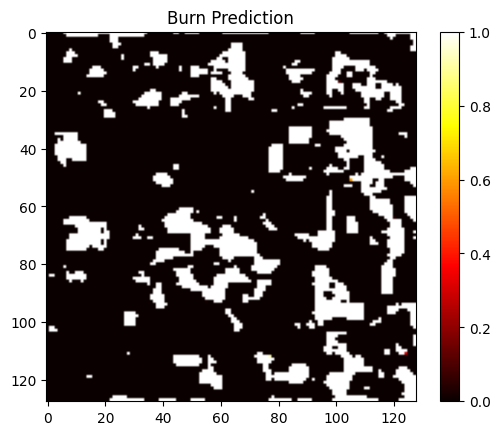

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(preds[0][:,:,0], cmap='hot')
plt.title("Burn Prediction")
plt.colorbar()
plt.show()

In [ ]:
loss, acc = model.evaluate(patches, preds)
print("Accuracy:", acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 827ms/step - accuracy: 0.9965 - loss: 1.0938e-04
Accuracy: 0.9965429306030273


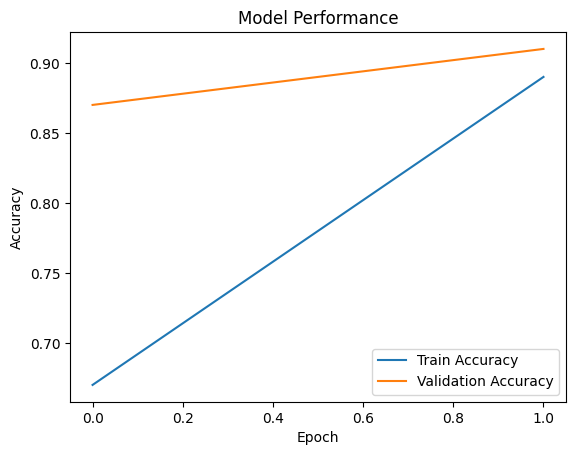

In [ ]:
import matplotlib.pyplot as plt

accuracy = [0.67, 0.89]
val_accuracy = [0.87, 0.91]

plt.plot(accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')

plt.legend()
plt.title("Model Performance")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

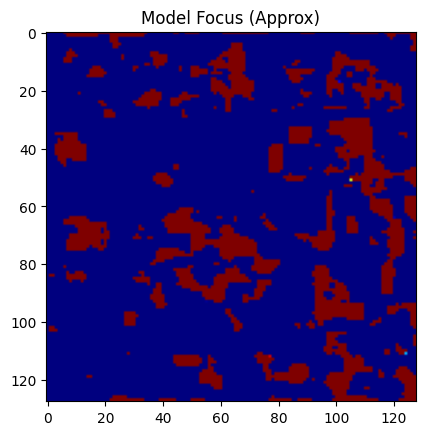

In [ ]:
plt.imshow(preds[0][:,:,0], cmap='jet')
plt.title("Model Focus (Approx)")
plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print(os.path.exists('/content/drive'))
print(os.path.exists('/content/drive/MyDrive'))

True
True


In [3]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Getting started.pdf', 'INDEX.HTML', 'a.html', 'b.html', 'C.HTML', 'd.html', 'e.html', 'f.html', 'g.html', 'hindi.pdf', 'imgtopdf_generated_1410201434010.pdf', 'imgtopdf_generated_1510201632058.pdf', 'imgtopdf_generated_1610201644008.pdf', 'imgtopdf_generated_1910201657054.pdf', 'imgtopdf_generated_2010201655022.pdf', 'imgtopdf_generated_2110201646053.pdf', 'imgtopdf_generated_2210201404040.pdf', 'imgtopdf_generated_2210201644033.pdf', 'IMG_20201023_185140 (1).jpg', 'IMG_20201023_185140.jpg', 'IMG_20201023_185730.jpg', 'IMG_20201023_185751.jpg', 'imgtopdf_generated_2610201432023.pdf', 'imgtopdf_generated_2710201454048.pdf', 'imgtopdf_generated_3110201439044.pdf', "Share 'imgtopdf_generated_0511201253043.pdf'.pdf", 'yugansha panjwani math pdf.pdf', 'yugansha panjwani🐼 hindi paper.pdf', 'Yugansha Panjwani science.pdf', 'shraddha Panjwani english.pdf', 'english exam🐼 yugansha panjwani🐼.pdf', 'shraddhapanjwani math.pdf', 'shraddhapanjwani p.e..pdf', 'sst yugansha Panjwa

In [4]:
import os

folder = '/content/drive/MyDrive/EarthEngineExports'

print("Folder exists:", os.path.exists(folder))

if os.path.exists(folder):
    print(os.listdir(folder))

Folder exists: True
['Punjab_small.tif', 'tiny_unet_punjab_small.keras', 'Punjab_small_2.tif', 'tiny_unet_punjab_small_v2.keras', 'Punjab_small_3.tif']


In [5]:
import rasterio

path = "/content/drive/MyDrive/EarthEngineExports/Punjab_small.tif"

with rasterio.open(path) as src:
    print("Opened successfully!")
    print("Shape:", src.shape)
    print("Bands:", src.count)

Opened successfully!
Shape: (2004, 2319)
Bands: 8


In [6]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/EarthEngineExports/tiny_unet_punjab_small.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [7]:
import json

notebook = "/content/stubble_burning_project_main.ipynb"

with open(notebook, "r", encoding="utf-8") as f:
    nb = json.load(f)

print("Total Cells:", len(nb["cells"]))

code = sum(1 for c in nb["cells"] if c["cell_type"] == "code")
text = sum(1 for c in nb["cells"] if c["cell_type"] == "markdown")

print("Code Cells:", code)
print("Markdown Cells:", text)

FileNotFoundError: [Errno 2] No such file or directory: '/content/stubble_burning_project_main.ipynb'

In [8]:
import os

for file in os.listdir("/content"):
    print(file)

.config
drive
sample_data


In [9]:
import os
from datetime import datetime

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".ipynb"):
            path = os.path.join(root, file)
            print(datetime.fromtimestamp(os.path.getmtime(path)))
            print(path)
            print("-" * 80)

2026-07-18 20:31:43
/content/drive/MyDrive/Colab Notebooks/stubble_burning_project_main.ipynb
--------------------------------------------------------------------------------


In [10]:
%cd /content

/content


In [11]:
!git clone https://github.com/Shradsssssss/stubble_burning_using_deepLearning.git

Cloning into 'stubble_burning_using_deepLearning'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.


In [12]:
%cd /content/stubble_burning_using_deepLearning

/content/stubble_burning_using_deepLearning


In [13]:
import os

for item in os.listdir():
    print(item)

README.md
.git
